#  GAN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
* https://www.kaggle.com/datasets/splcher/animefacedataset
* https://github.com/eriklindernoren/PyTorch-GAN

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении GAN.

## Задачи для самостоятельного решения

In [41]:
import os
import torch
from torchvision import transforms, utils
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

In [24]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


PyTorch version: 2.5.0+cu124
CUDA available: True
CUDA version: 12.4
Number of GPUs: 2
GPU 0: NVIDIA GeForce RTX 4090
GPU 1: NVIDIA GeForce RTX 4090


In [25]:
torch.cuda.set_device(0)
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: NVIDIA GeForce RTX 4090


In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [27]:
import kagglehub

path = kagglehub.dataset_download("splcher/animefacedataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\n.sedov\.cache\kagglehub\datasets\splcher\animefacedataset\versions\3


In [29]:
image_folder = 'anime/images'

<p class="task" id="1"></p>

1\. Создайте набор данных на основе архива `anime.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений. 

- [ ] Проверено на семинаре

In [37]:
class AnimeDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform
        self.image_files = os.listdir(image_folder)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_folder, self.image_files[idx])
        img = Image.open(image_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        
        return img

In [42]:
transform = transforms.Compose([
    transforms.Resize((500, 500)),  
    transforms.ToTensor(),          
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = AnimeDataset(image_folder, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


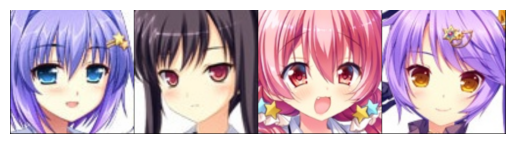

In [45]:
def show_images(dataloader):
    data_iter = iter(dataloader)
    images = next(data_iter)  

    
    images = images * 0.5 + 0.5
    grid = utils.make_grid(images)

    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

show_images(dataloader)

<p class="task" id="2"></p>

2\. Реализуйте архитектуру `DCGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры генерации изображений из случайного шума и сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

<p class="task" id="3"></p>

3\. Создайте наборы данных на основе архива `summer2winter_yosemite.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений, расположив изображения из одной пары рядом по горизонтали. 

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Реализуйте архитектуру `CycleGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры преобразования (в обе стороны) и  сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

## Обратная связь
- [ ] Хочу получить обратную связь по решению